# Usage Example of Pyspectrum
pyspectrum is a package that helps with handeling spectra.\
The package includes spectrum realization via xarray and other standard python tools.\
In here, the basic use of PySpectrum is presented.\
We'll load a spectrum and calibrate it and normlized it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create calibrated Spectrum 
from pyspectrum.core import Spectrum, Domain
from pyspectrum.calibration.detector_calibration import DetectorCalibration, StandardHPGeFWHMModel, PolynomialEnergyModel

# Loading a new spectrum
The spectrum is of Eu152, and there was not calibration yet.

In [2]:
path = '../Library/152Eu_calsource_10cm_85ks.txt'
spectrum = pd.read_csv(path, names=['counts'])
first_non_zero = np.where(spectrum["counts"]>0)[0][0]
#first_non_zero = 0
spectrum = spectrum[first_non_zero:].reset_index(drop=True)
spectrum['channel'] = spectrum.index

spectrum = Spectrum.from_dataframe(df=spectrum, channel_col="channel", counts_col="counts")

# calibration
domains = [(300,320),(1057,1082),(2544,2567),(3177,3202),(3597,3612),(3687,3707),(4687,4727)]
energies = [121.78, 344.28, 778.9, 964.08, 1085.8370, 1112.0760, 1408]
detector_calibration = DetectorCalibration(spectrum,
                                           known_axis_values=energies, peak_domains=domains,
                                          energy_model=PolynomialEnergyModel(2), fwhm_model=StandardHPGeFWHMModel())
energy_calib, fwhm_calib = detector_calibration.generate(energy_p0=(0,1,0), fwhm_p0=(0,1,0))
spectrum.set_axis_calibration(energy_calib)
spectrum.set_resolution_calibration(fwhm_calib)

Text(0, 0.5, 'Counts')

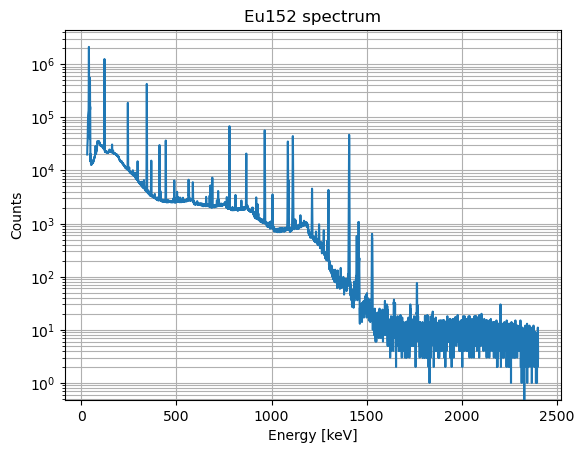

In [3]:
spectrum.plot(yscale='log')
plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts')

## findPeaks
An example how to find domains in which the counts are above snr

In [4]:
# identification of peaks
from pyspectrum.identification import Convolution
from pyspectrum.identification.snr import SNRFinder
from pyspectrum.identification.kernels.mexican_hat import gaussian_2_dev

In [5]:
conv = Convolution(resolution=spectrum.resolution_calib.apply, kernel=gaussian_2_dev, window_fwhm=4)
finder = SNRFinder(convolution=conv, n_sigma_signal_threshold=5, n_sigma_bg_threshold=2.5, persistence_factor=1)
domains = finder.find(spectrum)

Text(0, 0.5, 'counts')

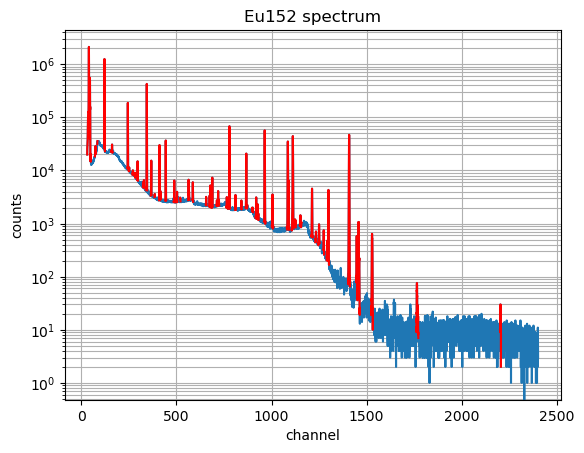

In [6]:
# note that using plot_all_peaks shows all the peaks in
plt.axes(yscale='log')
spectrum.plot()
for domain in domains:
    domain.plot(color='red')
plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('channel')
plt.ylabel('counts')
#plt.xlim([100, 500])
#plt.ylim([1e3, 2e6])